Regressione SVM

In [1]:
import numpy as np
from sklearn.svm import SVR
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = fetch_california_housing()
X = data.data
y = data.target

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# calcolo svm con modello lineare

svr_linear = SVR(kernel='linear', C=1.0, epsilon=5.0)
svr_linear.fit(X_scaled, y)
y_pred_lin = svr_linear.predict(X_scaled)
mse_linear = mean_squared_error(y, y_pred_lin)
r2_linear = r2_score(y, y_pred_lin)


In [5]:
# calcolo svm con modello rbf (stesso epsilon)

svr_rbf_narrow = SVR(kernel='rbf', C=1.0, epsilon=5.0)
svr_rbf_narrow.fit(X_scaled, y)
y_pred_narrow = svr_rbf_narrow.predict(X_scaled)
mse_narrow = mean_squared_error(y, y_pred_narrow)
r2_narrow = r2_score(y, y_pred_narrow)

In [7]:
# calcolo svm con modello rbf (epsilon maggiore)

svr_rbf_wide = SVR(kernel='rbf', C=1.0, epsilon=20.0)
svr_rbf_wide.fit(X_scaled, y)
y_pred_wide = svr_rbf_wide.predict(X_scaled)
mse_wide = mean_squared_error(y, y_pred_wide)
r2_wide = r2_score(y, y_pred_wide)

In [8]:
print("LINEAR")
print(f"\tMSE:\t{mse_linear}\n\tR2\t{r2_linear}")
print("RBF (eps = 5)")
print(f"\tMSE:\t{mse_narrow}\n\tR2\t{r2_narrow}")
print("RBF (eps = 20)")
print(f"\tMSE:\t{mse_wide}\n\tR2\t{r2_wide}")

LINEAR
	MSE:	1.588033628178144
	R2	-0.1926200820806987
RBF (eps = 5)
	MSE:	1.588033628178144
	R2	-0.1926200820806987
RBF (eps = 20)
	MSE:	1.5880336281781438
	R2	-0.19262008208069825


In [9]:
# plot dei modelli sugli stessi dati rendendo il dataset bidimensionale

import pandas as pd

pd.DataFrame(X, columns=data.feature_names)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [15]:
feature_index = 0 # scelta della colonna MedInc

# ordiniamo i punti in ordine crescente altrimenti la retta non ha senso nel grafico (sia le feature [X] che le label [y])

sort_idx = X_scaled[:, feature_index].argsort()
X_plot = X_scaled[sort_idx, feature_index]
y_pred_narrow_plot = y_pred_narrow[sort_idx]
y_pred_wide_plot = y_pred_wide[sort_idx]
y_pred_linear_plot = y_pred_lin[sort_idx]


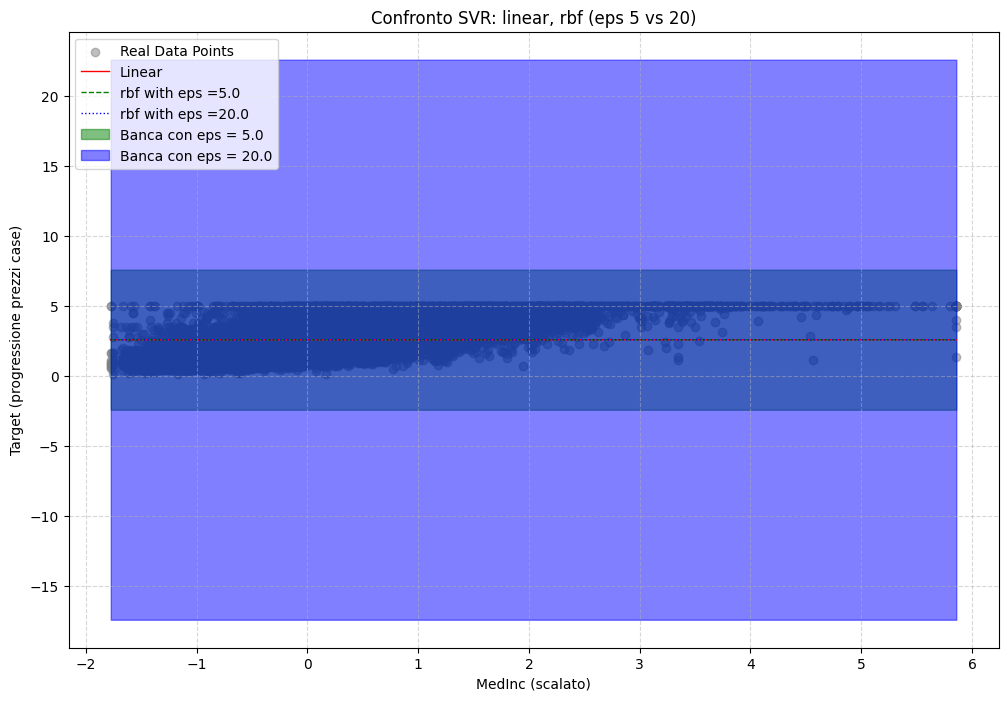

In [16]:
plt.figure(figsize=(12,8))
plt.scatter(X_scaled[:, feature_index], y, color="grey", alpha=0.5, label="Real Data Points")
plt.plot(X_plot, y_pred_linear_plot, color="red", linestyle="-", linewidth=1, label="Linear")
plt.plot(X_plot, y_pred_narrow_plot, color="green", linestyle="--", linewidth=1, label="rbf with eps =5.0")
plt.plot(X_plot, y_pred_wide_plot, color="blue", linestyle=":", linewidth=1, label="rbf with eps =20.0")

# rappresentazione di epsilon

# con epsilon -5 e +5
plt.fill_between(X_plot, y_pred_narrow - 5, y_pred_narrow + 5, color="green", alpha=0.5, label="Banca con eps = 5.0" )
# con epsilon -20 e +20
plt.fill_between(X_plot, y_pred_wide - 20, y_pred_wide + 20, color="blue", alpha=0.5, label="Banca con eps = 20.0" )

plt.title("Confronto SVR: linear, rbf (eps 5 vs 20)")
plt.xlabel("MedInc (scalato)")
plt.ylabel("Target (progressione prezzi case)")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
